# IMPORTANT

Two notebooks still reference the old 
select_ensemble_hashes_by_metadata_filter
 API:

compare_diversity.ipynb
polar_pairwise_diversity.ipynb
These would need 
select_ensemble_hashes_by_metadata_filter(save_dir, fn)
 replaced with:

python
select_ensembles(save_dir, filter_fn=fn)
The new API returns full info dicts instead of hashes, so downstream code accessing the results may also need adjustment.

In [ ]:
import sys
sys.path.append('..')
import os
import exp_diversity as exp_div
import utils.ensemble_utils as ens
from configs import env
import polars as pl
import utils.run_inference as run

ensembles = ens.select_ensembles(env.ENSEMBLES_ROOT,   
    filter_fn=lambda meta: meta['state'] == 'full'
)
print(f'Number of ensembles: {len(hashes)}')

TypeError: 'function' object is not iterable

In [2]:
df = pl.DataFrame({'hash': hashes})

df = df.with_columns(
    pl.Series('rho', [float(ens.load_metadata(env.ENSEMBLES_ROOT, h)['rho']) for h in hashes]),
    pl.Series('accuracy', [ens.get_ensemble_accuracies(ens.load_ensemble(env.ENSEMBLES_ROOT, h), run.get_cifar10_test_labels()).get('soft', None) for h in hashes]),
    pl.Series('comp_mean_acc', [ens.get_component_accuracies_by_hash(env.ENSEMBLES_ROOT, h).get('comp_mean_acc', None) for h in hashes]),
)

df = df.with_columns((df['accuracy'] - df['comp_mean_acc']).alias('accuracy_diff'))

div_scalar = [exp_div.get_diversity_results(h, env.ENSEMBLES_ROOT)[0] for h in hashes]
if div_scalar:
    df = df.with_columns([pl.Series(key, [d.get(key, None) for d in div_scalar]) for key in div_scalar[0].keys()])

df

/home/vlr/Workspaces/Topographic/ConTopo/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


hash,rho,accuracy,comp_mean_acc,accuracy_diff,kuncheva_correlation,iou_top_n,q_statistic,double_fault,interrater_agreement,disagreement
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""2572dd6f862bd42b""",0.0,0.9431,0.91425,0.02885,0.098272,0.689673,0.925903,0.046269,0.99327,0.078962
"""93a692bec0ef4e6d""",0.2,0.9443,0.91275,0.03155,0.097855,0.631328,0.92225,0.04666,0.981713,0.08118
"""5a082d77c912e6e1""",0.04,0.9448,0.91474,0.03006,0.098174,0.680638,0.926458,0.046044,0.99453,0.078431
"""0d9e88ef0fce8ae9""",0.008,0.9413,0.91064,0.03066,0.100228,0.697447,0.924068,0.048422,0.995385,0.081876


In [3]:
# Filter only to metrics in config
import yaml

with open('../configs/diversity.yaml') as f:
    cfg = yaml.safe_load(f)

metric_cols = cfg['metrics']
non_metric_cols = ['hash', 'rho', 'accuracy', 'comp_mean_acc', 'accuracy_diff']

df = df.select(non_metric_cols + metric_cols)

In [4]:
# Read consistency file
cons_df = pl.read_csv('../save/ResNet18/models/RSA_consistency.csv')
cons_df

model,mean,std,num_pairs,num_trials,message
str,f64,f64,i64,i64,str
"""CE_rho0""",0.835203,0.007658,45,10,null
"""CE_rho0.008""",0.832519,0.013229,45,10,null
"""CE_rho0.04""",0.739752,0.026546,45,10,null
"""CE_rho0.2""",0.597071,0.051318,45,10,null


In [5]:
# Extract rho from name
cons_df = cons_df.with_columns(
    pl.coalesce([
        # pl.col("model").str.extract(r"(\d+\.?\d*)rho", 1),  # Before rho
        pl.col("model").str.extract(r"rho(\d+\.?\d*)", 1),  # After rho
    ])
    .cast(pl.Float64)
    .alias("rho")
).filter(pl.col("rho").is_not_null())
cons_df

model,mean,std,num_pairs,num_trials,message,rho
str,f64,f64,i64,i64,str,f64
"""CE_rho0""",0.835203,0.007658,45,10,null,0.0
"""CE_rho0.008""",0.832519,0.013229,45,10,null,0.008
"""CE_rho0.04""",0.739752,0.026546,45,10,null,0.04
"""CE_rho0.2""",0.597071,0.051318,45,10,null,0.2


In [6]:
# Join the two tables on rho
# Note that this works now because there is one ensemble per rho 
# AND they are all composed of all trials
# AND they are composed only of such trials
# But remember that the rdm stats is calculated on every trial of a model, regardless of ensemble
# while the ensemble stats refer to the single ensemble with whatever components

joined_df = df.join(cons_df, on='rho')
joined_df = joined_df.drop('hash', 'num_pairs', 'num_trials', 'message', 'model', 'std')
joined_df = joined_df.rename({'mean': 'consistency'})
joined_df

rho,accuracy,comp_mean_acc,accuracy_diff,q_statistic,double_fault,disagreement,interrater_agreement,kuncheva_correlation,iou_top_n,consistency
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.9431,0.91425,0.02885,0.925903,0.046269,0.078962,0.99327,0.098272,0.689673,0.835203
0.008,0.9413,0.91064,0.03066,0.924068,0.048422,0.081876,0.995385,0.100228,0.697447,0.832519
0.04,0.9448,0.91474,0.03006,0.926458,0.046044,0.078431,0.99453,0.098174,0.680638,0.739752
0.2,0.9443,0.91275,0.03155,0.92225,0.04666,0.08118,0.981713,0.097855,0.631328,0.597071


In [7]:
pearson_corr = joined_df.to_pandas().corr(method="pearson")
spearman_corr = joined_df.to_pandas().corr(method="spearman")

(pearson_corr, spearman_corr)

(                           rho  accuracy  comp_mean_acc  accuracy_diff  \
 rho                   1.000000  0.515683      -0.044140       0.780244   
 accuracy              0.515683  1.000000       0.790511       0.088094   
 comp_mean_acc        -0.044140  0.790511       1.000000      -0.540428   
 accuracy_diff         0.780244  0.088094      -0.540428       1.000000   
 q_statistic          -0.778168  0.136781       0.632741      -0.841205   
 double_fault         -0.189278 -0.878300      -0.970554       0.371930   
 disagreement          0.341415 -0.608080      -0.950486       0.710522   
 interrater_agreement -0.966316 -0.444514       0.024512      -0.650547   
 kuncheva_correlation -0.531465 -0.910181      -0.808322       0.064271   
 iou_top_n            -0.989666 -0.597005      -0.083978      -0.683588   
 consistency          -0.974426 -0.671317      -0.110378      -0.742741   
 
                       q_statistic  double_fault  disagreement  \
 rho                     -0.7781

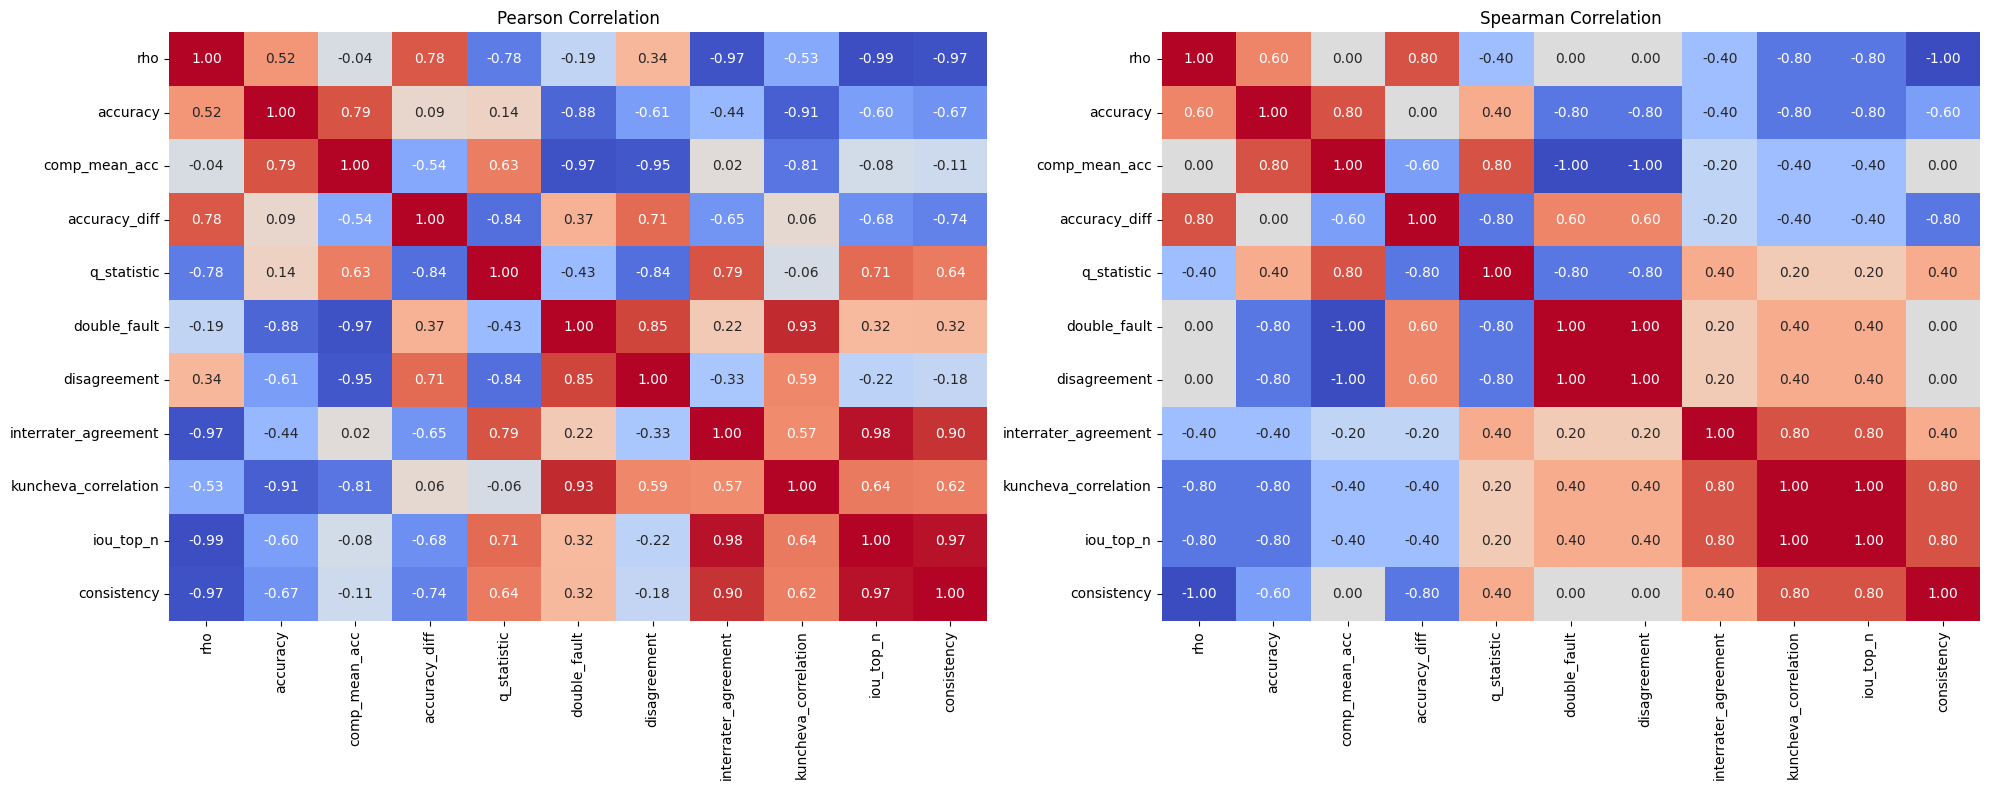

Figure saved to metrics_correlation_matrix.png


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

labels = joined_df.columns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(pearson_corr.to_numpy(), xticklabels=labels, yticklabels=labels,
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0], cbar=False)
axes[0].set_title("Pearson Correlation")

sns.heatmap(spearman_corr.to_numpy(), xticklabels=labels, yticklabels=labels,
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1], cbar=False)
axes[1].set_title("Spearman Correlation")

plt.tight_layout()

fig_path = os.path.join(os.path.dirname(__file__), 'metrics_correlation_matrix.png') if '__file__' in globals() else 'metrics_correlation_matrix.png'
plt.savefig(fig_path, dpi=200)
plt.show()
print(f"Figure saved to {fig_path}")